--- Data Definition: Generating Delivery Nodes ---
Successfully generated 20 nodes (1 Depot, 19 Delivery points).
Distance Matrix Shape: (20, 20)


/var/folders/73/rkxxc24d6b13v_wjp2frh5v80000gn/T/ipykernel_33123/2724539870.py:27: DeprecationWarning: `distance_matrix` is deprecated in favor of `scipy.spatial.distance.cdist` as of SciPy 1.18.0 and will be removed in SciPy 1.20.0.
  distance_matrix(df.values, df.values),
/var/folders/73/rkxxc24d6b13v_wjp2frh5v80000gn/T/ipykernel_33123/2724539870.py:27: DeprecationWarning: `minkowski_distance` is deprecated in favor of `scipy.spatial.distance.minkowski` as of SciPy 1.18.0 and will be removed in SciPy 1.20.0.
  distance_matrix(df.values, df.values),
/var/folders/73/rkxxc24d6b13v_wjp2frh5v80000gn/T/ipykernel_33123/2724539870.py:27: DeprecationWarning: `minkowski_distance_p` is deprecated in favor of `scipy.spatial.distance.minkowski` as of SciPy 1.18.0 and will be removed in SciPy 1.20.0.
  distance_matrix(df.values, df.values),


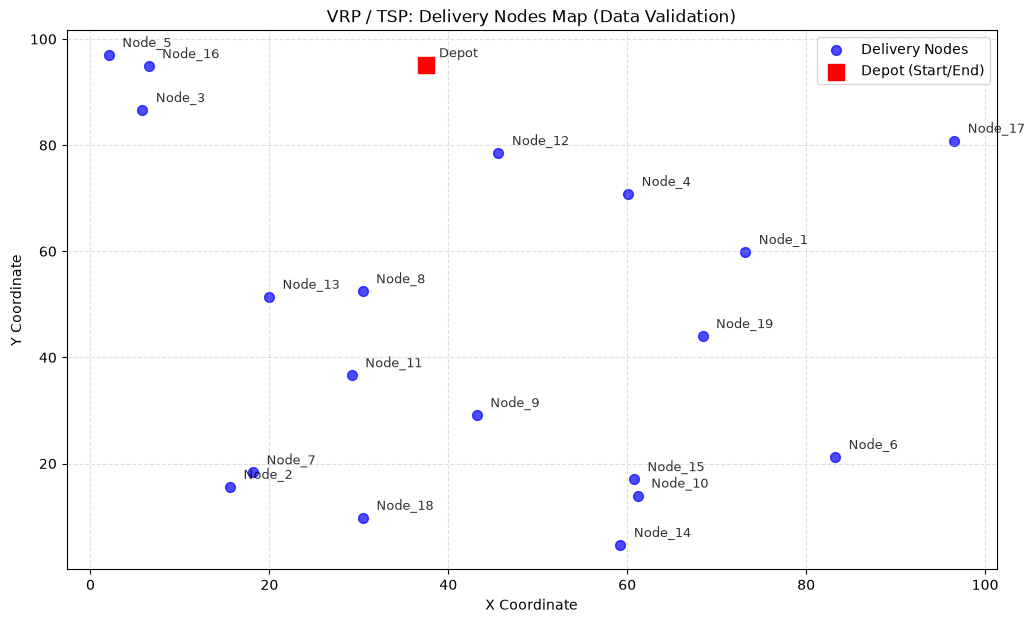

,Depot,Node_1,Node_2,Node_3,Node_4
Depot,0.000000,50.171360,82.421549,32.755369,33.198071
Node_1,50.171360,0.000000,72.642889,72.506609,17.058938
Node_2,82.421549,72.642889,0.000000,71.690251,70.915510
Node_3,32.755369,72.506609,71.690251,0.000000,56.557921
Node_4,33.198071,17.058938,70.915510,56.557921,0.000000


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import distance_matrix

def generate_delivery_nodes(num_nodes=20, seed=42):
    """
    Data Definition State
    Generate random coordinates for the depot (start/end) and delivery nodes.
    """
    print("--- Data Definition: Generating Delivery Nodes ---")
    
    # Set random seed for reproducibility
    np.random.seed(seed)
    
    # Generate random X, Y coordinates between 0 and 100
    coordinates = np.random.rand(num_nodes, 2) * 100
    
    # Create a DataFrame
    df = pd.DataFrame(coordinates, columns=['X', 'Y'])
    
    # Assign index names: Node 0 is the Depot
    df.index = ['Depot'] + [f'Node_{i}' for i in range(1, num_nodes)]
    
    # Calculate Euclidean Distance Matrix using SciPy
    dist_matrix = pd.DataFrame(
        distance_matrix(df.values, df.values),
        index=df.index,
        columns=df.index
    )
    
    print(f"Successfully generated {num_nodes} nodes (1 Depot, {num_nodes-1} Delivery points).")
    print("Distance Matrix Shape:", dist_matrix.shape)
    
    return df, dist_matrix

# Execute data generation (Generating 20 random points)
nodes_df, distance_df = generate_delivery_nodes(num_nodes=20)

# Visualization: Plotting the Delivery Map
plt.figure(figsize=(12, 7))

# Fix: Using .iloc for position-based indexing to avoid KeyError
plt.scatter(nodes_df['X'].iloc[1:], nodes_df['Y'].iloc[1:], c='blue', label='Delivery Nodes', s=50, alpha=0.7)
plt.scatter(nodes_df['X'].iloc[0], nodes_df['Y'].iloc[0], c='red', marker='s', label='Depot (Start/End)', s=120)

# Add annotations (labels) to each node
for i, idx in enumerate(nodes_df.index):
    plt.annotate(idx, (nodes_df['X'].iloc[i] + 1.5, nodes_df['Y'].iloc[i] + 1.5), fontsize=9, alpha=0.8)

plt.title('VRP / TSP: Delivery Nodes Map (Data Validation)')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# Display the top-left section of the computed distance matrix for validation
display(distance_df.iloc[:5, :5])

In [3]:
import pulp

def solve_tsp_pulp(distance_df):
    print("--- Mathematical Modeling & Optimization (PuLP) ---")
    
    # 1. Initialize the Problem (Minimization)
    prob = pulp.LpProblem("VRP_TSP_Optimization", pulp.LpMinimize)
    
    nodes = list(distance_df.index)
    num_nodes = len(nodes)
    
    # 2. Decision Variables
    # x[i, j] = 1 if the route goes from node i to node j, else 0
    x = pulp.LpVariable.dicts("x", 
                              ((i, j) for i in nodes for j in nodes if i != j), 
                              cat='Binary')
    
    # u[i] = continuous variable for MTZ subtour elimination
    u = pulp.LpVariable.dicts("u", 
                              (i for i in nodes if i != 'Depot'), 
                              lowBound=1, upBound=num_nodes-1, cat='Continuous')
    
    # 3. Objective Function: Minimize total distance
    prob += pulp.lpSum(distance_df.loc[i, j] * x[i, j] for i in nodes for j in nodes if i != j)
    
    # 4. Constraints
    # Constraint A: Exactly one outgoing edge from each node
    for i in nodes:
        prob += pulp.lpSum(x[i, j] for j in nodes if i != j) == 1
        
    # Constraint B: Exactly one incoming edge to each node
    for j in nodes:
        prob += pulp.lpSum(x[i, j] for i in nodes if i != j) == 1
        
    # Constraint C: MTZ Subtour Elimination
    for i in nodes:
        for j in nodes:
            if i != 'Depot' and j != 'Depot' and i != j:
                prob += u[i] - u[j] + num_nodes * x[i, j] <= num_nodes - 1
    
    # 5. Solve the problem
    print("Solving the Integer Programming model... (This may take a few seconds)")
    prob.solve()
    
    print(f"Optimization Status: {pulp.LpStatus[prob.status]}")
    print(f"Minimized Total Distance: {pulp.value(prob.objective):.2f}")
    
    # Extract the optimal route edges
    optimal_routes = [(i, j) for i in nodes for j in nodes if i != j and pulp.value(x[i, j]) == 1]
    
    return optimal_routes

# Execute optimization
optimal_edges = solve_tsp_pulp(distance_df)
print(f"Number of connected edges: {len(optimal_edges)}")

--- Mathematical Modeling & Optimization (PuLP) ---
Solving the Integer Programming model... (This may take a few seconds)
Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/erica/Desktop/arbitrage_bot/quant_env/lib/python3.14/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/73/rkxxc24d6b13v_wjp2frh5v80000gn/T/81a22f92dafb4ca79ba4a9653dee1fa9-pulp.mps -timeMode elapsed -solve -printingOptions all -solution /var/folders/73/rkxxc24d6b13v_wjp2frh5v80000gn/T/81a22f92dafb4ca79ba4a9653dee1fa9-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 387 COLUMNS
At line 3314 RHS
At line 3697 BOUNDS
At line 4116 ENDATA
Problem MODEL has 382 rows, 399 columns and 1786 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 315.779 - 0.00 seconds
Cgl0003I 0 fixed, 0 tightened bounds, 342 strengthened rows, 0 substitutions
Cgl0003I 0 fixed, 0 ti